# Sistema de QA com RAG para Múltiplos Tipos de Documentos

Este notebook demonstra a implementação e avaliação de um sistema de Perguntas e Respostas (Question Answering - QA)
utilizando Geração Aumentada por Recuperação (Retrieval Augmented Generation - RAG) em dois tipos de documentos: um PDF não estruturado e um DOCX com tabelas.
O objetivo é comparar o desempenho de diferentes modelos de linguagem (LLMs) gratuitos como leitores
e explorar estratégias de processamento e recuperação específicas para cada tipo de arquivo.

O notebook inclui:
1.  Instalação e importação de bibliotecas.
2.  Carregamento dos modelos (retriever e readers).
3.  Funções para processamento específico de PDF e DOCX.
4.  Implementação de busca híbrida (FAISS + BM25).
5.  Pipelines RAG específicos para cada tipo de documento.
6.  Definição de perguntas e respostas esperadas (ground truth).
7.  Execução dos testes com diferentes modelos.
8.  Implementação e cálculo de métricas de avaliação (Exact Match, F1 Score, Similaridade Semântica).
9.  Análise e visualização dos resultados.
10. Tratamento de erros e casos de borda.
11. Estruturação e documentação do código para relatório, vídeo e GitHub.

## 1. Instalação de Bibliotecas Necessárias

Este bloco de código instala todas as bibliotecas Python necessárias para executar o notebook.
A opção '-q' garante uma instalação silenciosa, exibindo menos output.
É importante executar esta célula antes de qualquer outra que dependa destas bibliotecas.
A versão do PyMuPDF é fixada para evitar potenciais problemas de compatibilidade.

In [ ]:
!pip install transformers sentence-transformers faiss-cpu "PyMuPDF<1.24.0" python-docx pandas torch accelerate langchain rank_bm25 -q

## 2. Importações e Configuração Inicial

Este bloco importa todas as classes e funções Python necessárias das bibliotecas instaladas.
Também inclui a definição de uma função utilitária para formatar a saída de texto.

In [ ]:
import os
import fitz  # PyMuPDF for PDF processing
import docx # python-docx for DOCX processing
import pandas as pd # pandas for data manipulation and result tables
import numpy as np # numpy for numerical operations, especially with embeddings
import torch # torch for deep learning models
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM # Hugging Face Transformers for reader models (BERT, XLM-R, Gemma)
from sentence_transformers import SentenceTransformer # Sentence-Transformers for the retriever model
import faiss # FAISS for efficient vector similarity search
import textwrap # textwrap for formatting output text
import re # re for regular expressions (used in DOCX processing)
from rank_bm25 import BM25Okapi # rank_bm25 for keyword-based search
from langchain.text_splitter import RecursiveCharacterTextSplitter
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


def wrap_text(text, width=120):
    """Formats output text by wrapping it to a specified width."""
    if text is None:
        return "N/A"
    return '\n'.join(textwrap.wrap(str(text), width=width))

print("Bibliotecas importadas com sucesso e configuração inicial concluída!")

Bibliotecas importadas com sucesso e configuração inicial concluída!


## Autenticação no Hugging Face

Este bloco de código realiza a autenticação no Hugging Face Hub.
É necessário para acessar e baixar modelos como o Gemma, que pode exigir autenticação.
A função `notebook_login()` abre um widget para inserir o token de acesso do Hugging Face.

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

## 3. Carregamento e Preparação dos Modelos

Este bloco carrega o modelo de embeddings (retriever) e os modelos de linguagem (readers) que serão comparados.
O retriever é usado para criar representações vetoriais (embeddings) dos chunks de texto e das perguntas.
Os readers (modelos de Q&A) são usados para gerar as respostas com base nos chunks recuperados.
O modelo Gemma é carregado separadamente devido às suas características (generativo) e requisitos de memória/dispositivo.
Foi selecionado o modelo 'intfloat/multilingual-e5-base' como retriever para potencial melhor desempenho em domínios diversos.

In [ ]:
model_names = {
    "BERT-pt": "pierreguillou/bert-base-cased-squad-v1.1-portuguese",
    "XLM-RoBERTa-multi": "deepset/xlm-roberta-base-squad2",
    "Gemma-2b-it": "google/gemma-2b-it"
}

retriever_model_name = 'intfloat/multilingual-e5-base'
print(f"Carregando modelo de embeddings (Retriever): {retriever_model_name}...")
try:
    retriever_model = SentenceTransformer(retriever_model_name)
    print("Modelo de embeddings carregado com sucesso.\n")
except Exception as e:
    print(f"Error loading the retriever model {retriever_model_name}: {e}")
    retriever_model = None
    print("Aviso: O modelo Retriever falhou ao carregar. A busca híbrida não funcionará.")

readers = {}
gemma_tokenizer = None
gemma_model = None

print("Carregando modelos de Leitura (Readers)...")
for name, path in model_names.items():
    print(f"  > Carregando modelo: {name}...")
    try:
        if "gemma" in name.lower():
            if torch.cuda.is_available():
                gemma_tokenizer = AutoTokenizer.from_pretrained(path)
                gemma_model = AutoModelForCausalLM.from_pretrained(path, torch_dtype=torch.bfloat16, device_map="auto")
            else:
                print(f"  > CUDA não disponível. Carregando Gemma ({name}) na CPU (pode ser lento e exigir muita RAM)...")
                gemma_tokenizer = AutoTokenizer.from_pretrained(path)
                gemma_model = AutoModelForCausalLM.from_pretrained(path, torch_dtype=torch.bfloat16)
        else:
            readers[name] = pipeline("question-answering", model=path, tokenizer=path, device=0 if torch.cuda.is_available() else -1)
        print(f"  > Modelo {name} carregado com sucesso.")
    except Exception as e:
        print(f"  > Error loading model {name} from {path}: {e}")
        readers[name] = None
        if "gemma" in name.lower():
             gemma_tokenizer = None
             gemma_model = None
        print(f"  > Aviso: O modelo {name} falhou ao carregar.")

if retriever_model is None or (not any(readers.values()) and (gemma_tokenizer is None or gemma_model is None)):
    print("\nWarning: Um ou mais modelos essenciais (Retriever ou Readers) falharam ao carregar. As etapas subsequentes podem não funcionar corretamente.")
else:
    print("\nTodos os modelos essenciais foram carregados com sucesso (ou com avisos de falha individual).")

Carregando modelo de embeddings (Retriever): intfloat/multilingual-e5-base...
Modelo de embeddings carregado com sucesso.

Carregando modelos de Leitura (Readers)...
  > Carregando modelo: BERT-pt...


Device set to use cuda:0


  > Modelo BERT-pt carregado com sucesso.
  > Carregando modelo: XLM-RoBERTa-multi...


Device set to use cuda:0


  > Modelo XLM-RoBERTa-multi carregado com sucesso.
  > Carregando modelo: Gemma-2b-it...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  > Modelo Gemma-2b-it carregado com sucesso.

Todos os modelos essenciais foram carregados com sucesso (ou com avisos de falha individual).


### 3.1. Carregamento de Modelo Especializado (Table Question Answering - TAPAS)
Para o desafio específico de responder perguntas sobre as tabelas complexas do documento DOCX, carregamos um modelo da família TAPAS (Table Parser). Estes modelos são pré-treinados para entender a estrutura de dados tabulares e responder a perguntas em linguagem natural diretamente sobre eles. Esta é uma abordagem especializada que contrasta com o método RAG genérico usado para o PDF.

In [ ]:
#@title 3.1 Carregamento do Pipeline Especializado (Table Question Answering - TAPAS)

from transformers import pipeline

# Define o nome do modelo TAPAS a ser usado
tapas_model_name = 'google/tapas-base-finetuned-sqa'
tapas_pipeline = None

print(f"Carregando pipeline especializado em tabelas: {tapas_model_name}...")
try:
    # Carrega o pipeline de 'table-question-answering' diretamente
    tapas_pipeline = pipeline("table-question-answering", model=tapas_model_name)
    print("Pipeline TAPAS carregado com sucesso!")
except Exception as e:
    print(f"Erro ao carregar o pipeline TAPAS: {e}")

Carregando pipeline especializado em tabelas: google/tapas-base-finetuned-sqa...


TAPAS models are not usable since `tensorflow_probability` can't be loaded. It seems you have `tensorflow_probability` installed with the wrong tensorflow version. Please try to reinstall it following the instructions here: https://github.com/tensorflow/probability.
Device set to use cuda:0


Pipeline TAPAS carregado com sucesso!


## 4. Funções de Processamento de Documentos e RAG

Este bloco contém as funções principais para o sistema RAG.
Inclui funções para processar PDFs e DOCXs, criar índices de busca (FAISS para semântica, BM25 para palavras-chave),
realizar busca híbrida e obter respostas dos modelos de leitura.
As funções de processamento de documentos e de busca híbrida foram aprimoradas e incluem tratamento de erros abrangente.
As estratégias específicas para DOCX (chunking focado em tabelas, peso maior para BM25) estão detalhadas aqui.

In [ ]:
# --- Funções para Processar Documentos (PDF e DOCX) ---

def process_pdf(file_path, chunk_size=768, chunk_overlap=50):
    """
    Extrai texto de um PDF e o divide em pedaços menores (chunks) usando técnica recursiva.
    Inclui tratamento de erros para operações de arquivo e processamento de texto.
    Argumentos:
        file_path (str): Caminho para o arquivo PDF.
        chunk_size (int): Tamanho máximo de cada chunk de texto.
        chunk_overlap (int): Quantidade de texto sobreposto entre chunks consecutivos.
    Retorna:
        list: Uma lista de strings, onde cada string é um chunk de texto do PDF.
              Retorna uma lista vazia em caso de erro ou se o documento estiver vazio.
    """
    chunks = []
    full_text = ""
    try:
        # Verifica se o arquivo existe
        if not os.path.exists(file_path):
            print(f"Error: Arquivo PDF não encontrado em '{file_path}'.")
            return []

        # Abre o documento PDF usando PyMuPDF
        doc = fitz.open(file_path)
        # Verifica se o documento tem páginas
        if doc.page_count == 0:
             print(f"Warning: Documento PDF '{file_path}' não tem páginas.")
             doc.close()
             return []

        # Extrai texto de cada página
        for page in doc:
            full_text += page.get_text()
        doc.close() # Fecha o documento para liberar recursos

        # Verifica se o texto extraído está vazio após a extração
        if not full_text.strip():
            print(f"Warning: Documento PDF '{file_path}' está vazio ou contém apenas espaços em branco após a extração.")
            return []

        # Limpa espaços em branco excessivos (múltiplos espaços/quebras de linha por um único espaço)
        full_text = re.sub(r'\s+', ' ', full_text).strip()

        # Verifica se o texto ainda está vazio após a limpeza
        if not full_text:
             print(f"Warning: Documento PDF '{file_path}' resultou em texto vazio após a limpeza.")
             return []


        # Divide o texto longo em chunks menores usando RecursiveCharacterTextSplitter.
        # Separadores são definidos para tentar manter a integridade de frases/parágrafos.
        text_splitter = RecursiveCharacterTextSplitter(
            separators=["\n\n", "\n", "."," ", ""], # Separadores: parágrafos, linhas, frases, palavras, caracteres
            chunk_size=chunk_size, # Tamanho máximo desejado para cada chunk
            chunk_overlap=chunk_overlap, # Sobreposição entre chunks para manter contexto
            length_function=len # Função para calcular o tamanho dos chunks (contagem de caracteres)
        )
        chunks = text_splitter.split_text(full_text)
        # Filtra chunks vazios ou que contenham apenas espaços em branco resultantes da divisão
        chunks = [chunk for chunk in chunks if chunk.strip()]

        # Verifica se a divisão resultou em chunks válidos
        if not chunks:
             print(f"Warning: Documento PDF '{file_path}' não resultou em chunks válidos após a divisão.")


    except FileNotFoundError:
        print(f"Error: Erro de arquivo ao processar PDF '{file_path}'.")
        return []
    except Exception as e:
        print(f"Error: Erro inesperado ao processar arquivo PDF '{file_path}': {e}")
        return []

    # Retorna a lista de chunks de texto
    return chunks

def process_docx_improved(file_path):
    """
    Extrai texto e dados de tabelas de um DOCX, criando chunks granulares (por linha/campo de tabela)
    e chunks holísticos (resumo por tabela) para melhorar a recuperação de contexto.
    Inclui tratamento de erros para operações de arquivo e parsing de docx.
    Argumentos:
        file_path (str): Caminho para o arquivo DOCX.
    Retorna:
        list: Uma lista de strings, onde cada string é um chunk de texto do DOCX (parágrafos ou dados de tabela).
              Retorna uma lista vazia em caso de erro ou se o documento estiver vazio/sem conteúdo significativo.
    """
    chunks = []
    current_table_context = {} # Mantém o contexto da tabela atual (título, nome local/federal)
    try:
        # Verifica se o arquivo existe
        if not os.path.exists(file_path):
            print(f"Error: Arquivo DOCX não encontrado em '{file_path}'.")
            return []

        # Abre o documento DOCX usando python-docx
        doc = docx.Document(file_path)

        # Verifica se o corpo do documento existe e tem algum conteúdo significativo (texto ou tabelas)
        has_content = False
        if doc.element.body:
             for block in doc.element.body:
                if isinstance(block, docx.oxml.text.paragraph.CT_P):
                    p = docx.text.paragraph.Paragraph(block, doc)
                    if p.text.strip():
                        has_content = True
                        break
                elif isinstance(block, docx.oxml.table.CT_Tbl):
                     table = docx.table.Table(block, doc)
                     if table.rows and any(cell.text.strip() for row in table.rows for cell in row.cells):
                          has_content = True
                          break

        if not has_content:
             print(f"Warning: Documento DOCX '{file_path}' está vazio ou não contém texto/tabelas significativas.")
             return []


        # Itera sobre os blocos do corpo do documento (parágrafos, tabelas, etc.)
        for block in doc.element.body:
            # Se for um Parágrafo (CT_P), pode ser um título de tabela ou outro texto relevante
            if isinstance(block, docx.oxml.text.paragraph.CT_P):
                try:
                    p = docx.text.paragraph.Paragraph(block, doc)
                    text = p.text.strip()
                    if text: # Processa parágrafos não vazios
                        # Verifica se o parágrafo é um indicador de título de tabela (específico deste documento)
                        if text.startswith("TABELA DE"):
                            current_table_context = {'title': text} # Define o título como contexto da próxima tabela
                        else:
                             # Divide outros textos de parágrafo em chunks menores
                             text_splitter = RecursiveCharacterTextSplitter(
                                separators=["\n\n", "\n", "."," ", ""],
                                chunk_size=200, # Chunks menores para texto geral
                                chunk_overlap=20,
                                length_function=len
                             )
                             paragraph_chunks = text_splitter.split_text(text)
                             # Adiciona chunks válidos (não vazios) à lista principal
                             chunks.extend([chunk for chunk in paragraph_chunks if chunk.strip()])
                except Exception as e:
                    print(f"Warning: Erro ao processar parágrafo em DOCX '{file_path}': {e}")


            # Se for uma Tabela (CT_Tbl)
            if isinstance(block, docx.oxml.table.CT_Tbl):
                try:
                    table = docx.table.Table(block, doc)
                    if not table.rows:
                        continue # Pula tabelas vazias

                    # Tenta identificar se é uma "tabela de nomes" (1 linha com LFCES/NFCES)
                    first_cell_text = ""
                    if table.rows and table.rows[0].cells and table.rows[0].cells[0]:
                        first_cell_text = table.rows[0].cells[0].text.strip()

                    # Regex para identificar nomes de tabela como LFCES001, NFCES123 etc.
                    is_name_table = (len(table.rows) == 1 and re.match(r'^[A-Z]{2,}[0-9]{3,}', first_cell_text))

                    # Se for uma tabela de nomes, atualiza o contexto da próxima tabela de dados
                    if is_name_table:
                        local_name = table.rows[0].cells[0].text.strip() if len(table.rows[0].cells) > 0 else ''
                        federal_name = table.rows[0].cells[1].text.strip() if len(table.rows[0].cells) > 1 else ''
                        current_table_context['local_name'] = local_name
                        if federal_name:
                            current_table_context['federal_name'] = federal_name
                        continue # Pula para o próximo bloco (espera-se uma tabela de dados em seguida)

                    # Se for uma tabela de dados (e temos um contexto de título/nome)
                    if not table.rows: continue # Garante que a tabela ainda tem linhas
                    headers = [cell.text.strip().lower() for cell in table.rows[0].cells] # Cabeçalhos em minúsculas para comparação case-insensitive
                    # Verifica se há cabeçalhos essenciais e se há um contexto de tabela
                    if any(h in headers for h in ['nome do campo', 'descrição']) and ('title' in current_table_context or 'local_name' in current_table_context):

                        individual_sentences = [] # Chunks para cada linha/campo da tabela
                        # Prioriza o nome local do contexto, fallback para o título, depois padrão
                        table_name = current_table_context.get('local_name', current_table_context.get('title', 'Tabela Desconhecida'))

                        # Cria partes do resumo da tabela inteira
                        full_table_summary_parts = [f"Detalhes da tabela '{table_name}':"]
                        # Adiciona nome federal ao resumo se disponível no contexto
                        if 'federal_name' in current_table_context and current_table_context['federal_name']:
                             full_table_summary_parts[0] += f" (Nome Federal: {current_table_context['federal_name']})"

                        # Obtém índices dos cabeçalhos essenciais de forma segura, -1 se não encontrados
                        field_name_idx = headers.index('nome do campo') if 'nome do campo' in headers else -1
                        description_idx = headers.index('descrição') if 'descrição' in headers else -1
                        type_idx = headers.index('tipo') if 'tipo' in headers else -1
                        pk_idx = headers.index('primary key') if 'primary key' in headers else -1
                        fk_idx = headers.index('foreign key') if 'foreign key' in headers else -1

                        # Determina o índice máximo necessário para verificar o tamanho dos dados da linha
                        max_idx = max(field_name_idx, description_idx, type_idx, pk_idx, fk_idx)

                        # Itera sobre as linhas de dados (pula a linha de cabeçalho)
                        for row_index, row in enumerate(table.rows[1:]):
                            try:
                                row_data = [cell.text.strip() for cell in row.cells]

                                # Verifica se a linha tem colunas suficientes para os cabeçalhos esperados
                                if len(row_data) <= max_idx:
                                     continue # Pula linhas com colunas insuficientes

                                # Extrai dados usando os índices de forma segura
                                field_name = row_data[field_name_idx] if 0 <= field_name_idx < len(row_data) else ''
                                description = row_data[description_idx] if 0 <= description_idx < len(row_data) else ''
                                field_type = row_data[type_idx] if 0 <= type_idx < len(row_data) else ''
                                primary_key = row_data[pk_idx].lower() if 0 <= pk_idx < len(row_data) else ''
                                foreign_key = row_data[fk_idx] if 0 <= fk_idx < len(row_data) else ''

                                # Condição para criar um chunk significativo para um campo: deve ter nome e descrição
                                if field_name and description:
                                    # Constrói a sentença detalhada para este campo
                                    sentence = f"Na tabela '{table_name}', o campo '{field_name}' tem a descrição: '{description}'."
                                    if field_type: sentence += f" É do tipo '{field_type}'."
                                    if 'yes' in primary_key: sentence += " Este campo é parte da chave primária."
                                    if foreign_key: sentence += f" É uma chave estrangeira para a tabela '{foreign_key}'."
                                    individual_sentences.append(sentence.strip())

                                    # Adiciona informações chave à lista de partes do resumo da tabela
                                    summary_part = f"- Campo '{field_name}': {description}."
                                    if field_type: summary_part += f" Tipo: {field_type}."
                                    if 'yes' in primary_key: summary_part += f" PK."
                                    if foreign_key: summary_part += f" FK para '{foreign_key}'."
                                    full_table_summary_parts.append(summary_part.strip())
                            except Exception as e:
                                print(f"Warning: Erro ao processar linha {row_index+2} na tabela '{table_name}' em DOCX '{file_path}': {e}")
                                continue # Continua processando as próximas linhas

                        # Ao final da tabela, adiciona os chunks gerados à lista principal
                        if individual_sentences:
                            chunks.extend(individual_sentences) # Adiciona todos os chunks de campos individuais
                            full_table_summary = " ".join(full_table_summary_parts).strip()
                            # Adiciona o resumo da tabela inteira apenas se contiver mais do que apenas o título
                            if len(full_table_summary_parts) > 1:
                                 chunks.append(full_table_summary)

                        # Limpa o contexto APÓS processar a tabela de dados
                        current_table_context = {}
                    else:
                         # Se for uma tabela, mas não uma tabela de dados reconhecida com cabeçalhos,
                         # ou se não houver contexto precedente (título/tabela de nome),
                         # imprime um aviso e pula a adição de chunks detalhados para ela.
                         table_name_context = current_table_context.get('local_name', current_table_context.get('title', 'Tabela Desconhecida'))
                         if table.rows and any(cell.text.strip() for row in table.rows for cell in row.cells):
                            print(f"Warning: Pulando tabela com formato não reconhecido ou contexto ausente após '{table_name_context}' em DOCX '{file_path}'. Cabeçalhos encontrados: {headers if table.rows else 'Nenhum'}.")
                         current_table_context = {} # Reseta o contexto em caso de erro de processamento de tabela
                except Exception as e:
                    print(f"Warning: Erro ao processar tabela em DOCX '{file_path}': {e}")
                    current_table_context = {} # Reseta o contexto em caso de erro de processamento de tabela


    except FileNotFoundError:
        print(f"Error: Erro de arquivo ao processar DOCX '{file_path}'.")
        return []
    except Exception as e:
        print(f"Error: Erro inesperado ao processar arquivo DOCX '{file_path}': {e}")
        return []

    # Filtro final para remover quaisquer chunks vazios que possam ter passado
    return [chunk for chunk in chunks if chunk.strip()]


# --- Função para criar o índice vetorial com FAISS ---
def create_faiss_index(chunks, model):
    """
    Cria um índice FAISS a partir dos embeddings dos chunks de texto.
    Inclui tratamento de erros para a criação de embeddings e do índice.
    Argumentos:
        chunks (list): Lista de chunks de texto.
        model (SentenceTransformer): Modelo de embeddings (retriever).
    Retorna:
        faiss.IndexFlatIP ou None: O índice FAISS criado ou None em caso de erro/chunks vazios.
    """
    if not chunks: # Retorna None se não houver chunks para indexar
        print("Nenhum chunk para criar índice FAISS.")
        return None

    if model is None: # Retorna None se o modelo retriever não foi carregado
         print("Error: Modelo Retriever não carregado, não é possível criar índice FAISS.")
         return None

    print(f"Criando embeddings para {len(chunks)} chunks de texto...")
    embeddings = None
    try:
        # Verifica se o modelo tem o método de codificação necessário
        if not hasattr(model, 'encode'):
          raise TypeError("O modelo fornecido não tem um método 'encode'.")

        # Cria embeddings para os chunks
        # Batch size e manipulação de dispositivo podem ser adicionados para maior robustez/eficiência
        embeddings = model.encode(chunks, show_progress_bar=True)

        # Converte embeddings para numpy array e garante o tipo float32 para FAISS
        embeddings_np = np.array(embeddings).astype('float32')
        # Verifica se os embeddings foram gerados corretamente
        if embeddings_np.size == 0 or embeddings_np.shape[1] == 0:
            raise ValueError("Embeddings não puderam ser gerados ou têm dimensões zero.")

        # Normaliza os embeddings para busca de similaridade de cosseno (produto interno após normalização L2)
        faiss.normalize_L2(embeddings_np)
        # Cria um índice FAISS Flat com produto interno
        index = faiss.IndexFlatIP(embeddings_np.shape[1])
        # Adiciona os embeddings ao índice
        index.add(embeddings_np)
        print("Índice FAISS criado com sucesso.")
        return index
    except Exception as e:
        print(f"Error ao criar índice FAISS: {e}")
        return None


# --- Função para busca híbrida (FAISS + BM25) ---
def hybrid_search(question, text_chunks, index_faiss, model_retriever, bm25_index, top_k=7, bm25_weight=0.5):
    """
    Realiza uma busca híbrida combinando os resultados do FAISS (semântico) e do BM25 (palavra-chave).
    Inclui tratamento de erros para as operações de busca.
    Permite ajustar o peso do BM25 por chamada.
    Argumentos:
        question (str): A pergunta a ser respondida.
        text_chunks (list): Lista de todos os chunks de texto do documento.
        index_faiss (faiss.IndexFlatIP): O índice FAISS para busca semântica.
        model_retriever (SentenceTransformer): O modelo de embeddings para codificar a pergunta.
        bm25_index (BM25Okapi): O índice BM25 para busca por palavra-chave.
        top_k (int): O número de chunks mais relevantes a serem retornados.
        bm25_weight (float): O peso a ser dado aos scores do BM25 na combinação (0.0 a 1.0).
    Retorna:
        list: Uma lista dos chunks de texto mais relevantes ordenados por score combinado.
              Retorna uma lista vazia em caso de erro ou se nenhum chunk relevante for encontrado.
    """
    # Verifica se os componentes essenciais estão disponíveis
    if not text_chunks or index_faiss is None or bm25_index is None or model_retriever is None:
        print("Pulando busca híbrida devido a chunks, índices ou modelo retriever ausentes.")
        return []

    relevant_indices = set() # Conjunto para armazenar índices únicos encontrados por ambas as buscas
    faiss_results = {} # Dicionário para armazenar scores do FAISS por índice
    bm25_results = {} # Dicionário para armazenar scores do BM25 por índice

    try:
        # 1. Busca Semântica (FAISS)
        # Verifica se o modelo retriever tem o método de codificação
        if not hasattr(model_retriever, 'encode'):
            raise TypeError("O modelo retriever fornecido não tem um método 'encode'.")

        # Codifica a pergunta para obter o embedding
        question_embedding = model_retriever.encode([question])
        question_embedding = np.array(question_embedding).astype('float32')
        # Normaliza o embedding da pergunta
        faiss.normalize_L2(question_embedding)

        # Verifica se a dimensão do embedding da pergunta corresponde à dimensão do índice FAISS
        if index_faiss is not None and question_embedding.shape[1] != index_faiss.d:
             print(f"Error: Dimensão do embedding da pergunta ({question_embedding.shape[1]}) não corresponde à dimensão do índice FAISS ({index_faiss.d}). Pulando busca FAISS.")
        elif index_faiss is not None:
            # Realiza a busca no índice FAISS
            distances, faiss_indices = index_faiss.search(question_embedding, top_k)
            # Processa os resultados da busca FAISS
            if distances is not None and faiss_indices is not None and faiss_indices[0] is not None:
                faiss_results = {idx: score for idx, score in zip(faiss_indices[0], distances[0])}
                relevant_indices.update(faiss_results.keys()) # Adiciona índices encontrados pelo FAISS
            else:
                print("Warning: Busca FAISS retornou resultados vazios ou None.")

    except Exception as e:
        print(f"Error durante a busca FAISS: {e}")


    try:
        # 2. Busca por Palavra-Chave (BM25)
        # Tokeniza a pergunta para BM25
        tokenized_query = question.lower().split()
        # Verifica se o índice BM25 foi construído e se a consulta tokenizada não está vazia
        if bm25_index and tokenized_query:
            bm25_scores = bm25_index.get_scores(tokenized_query)
            if bm25_scores is not None and len(bm25_scores) == len(text_chunks): # Verifica se os scores correspondem aos chunks
                # Filtra índices com scores maiores que zero antes de pegar o top_k
                non_zero_scores_indices = [i for i, score in enumerate(bm25_scores) if score > 0]
                # Pega os top_k índices entre aqueles com scores diferentes de zero
                num_bm25_results = min(top_k, len(non_zero_scores_indices))
                if num_bm25_results > 0:
                    bm25_indices = np.array(non_zero_scores_indices)[np.argsort(bm25_scores[non_zero_scores_indices])[::-1][:num_bm25_results]]
                    # Armazena scores do BM25 por índice
                    bm25_results = {idx: bm25_scores[idx] for idx in bm25_indices}
                    relevant_indices.update(bm25_results.keys()) # Adiciona índices encontrados pelo BM25
            else:
                 # print("Warning: BM25 get_scores retornou None ou scores não correspondem aos chunks.") # Debugging
                 pass # Silenciosamente ignora se BM25 scores são inválidos

        # else: bm25_results permanece vazio se o índice não existe ou a consulta é vazia
    except Exception as e:
        print(f"Error durante a busca BM25: {e}")


    # 3. Combina os resultados
    combined_scores = {}
    # Normaliza os scores do BM25 para a escala 0-1 para combinar com os scores do FAISS
    # Lida com o caso em que não há resultados BM25 ou todos os scores são 0 para evitar divisão por zero
    max_bm25_score = max(bm25_results.values()) if bm25_results else 1.0
    bm25_results_normalized = {idx: score / max_bm25_score if max_bm25_score > 0 else 0 for idx, score in bm25_results.items()}

    # Itera sobre todos os índices relevantes encontrados (união de FAISS e BM25)
    for idx in relevant_indices:
        faiss_score = faiss_results.get(idx, 0.0) # Usa 0.0 como score padrão se o índice não foi encontrado pelo FAISS
        bm25_score = bm25_results_normalized.get(idx, 0.0) # Usa 0.0 como score padrão se o índice não foi encontrado pelo BM25
        # Combina os scores usando o peso especificado para o BM25
        combined_scores[idx] = faiss_score * (1 - bm25_weight) + bm25_score * bm25_weight

    # Pega os top_k índices com base nos scores combinados, ordenados de forma descendente
    # Retorna lista vazia se não houver scores combinados
    if not combined_scores:
        # print("Nenhum chunk relevante encontrado após a busca híbrida.") # Debugging
        return []

    sorted_indices = sorted(combined_scores.keys(), key=lambda idx: combined_scores[idx], reverse=True)[:top_k]

    # Retorna os chunks de texto correspondentes aos índices ordenados
    # Garante que os índices são válidos (dentro dos limites da lista de chunks)
    valid_indices = [i for i in sorted_indices if 0 <= i < len(text_chunks)]

    return [text_chunks[i] for i in valid_indices]

# --- Funções de Q&A (Extrativo e Generativo) ---

# Helper function to get the correct model based on name, with error handling
def get_reader_model(model_name, readers, gemma_tokenizer, gemma_model):
    """
    Retorna o modelo/tokenizer ou pipeline apropriado com base no nome do modelo.
    Inclui tratamento de erros para modelos não carregados.
    Argumentos:
        model_name (str): Nome do modelo (chave no dicionário model_names).
        readers (dict): Dicionário de pipelines de modelos extrativos.
        gemma_tokenizer (AutoTokenizer): Tokenizer para o modelo Gemma.
        gemma_model (AutoModelForCausalLM): Modelo para o Gemma.
    Retorna:
        Pipeline ou tuple (tokenizer, model): O objeto do modelo apropriado.
    Levanta:
        ValueError: Se os componentes do modelo Gemma não estiverem carregados.
        ValueError: Se o modelo extrativo especificado não estiver carregado.
        ValueError: Se o nome do modelo for desconhecido.
    """
    if "gemma" in model_name.lower():
        # Verifica se os componentes do Gemma foram carregados
        if gemma_tokenizer is None or gemma_model is None:
             raise ValueError(f"Componentes do modelo Gemma ('{model_name}') não carregados.")
        return (gemma_tokenizer, gemma_model) # Retorna tokenizer e modelo para Gemma
    elif model_name in readers:
        # Verifica se o modelo extrativo especificado foi carregado
        if readers[model_name] is None:
             raise ValueError(f"Modelo extrativo '{model_name}' não carregado.")
        return readers[model_name] # Retorna o objeto pipeline para modelos extrativos
    else:
        # Levanta erro se o nome do modelo não for reconhecido
        raise ValueError(f"Nome de modelo desconhecido: {model_name}")

# --- Função de Q&A para os modelos Extrativos ---
def get_answer_extractive(question, relevant_contexts, reader_pipeline):
    """
    Realiza Q&A usando um modelo extrativo nos contextos relevantes fornecidos.
    Remove os parâmetros de índice, pois a busca híbrida é feita antes.
    Inclui tratamento de erros para o processo de Q&A.
    Argumentos:
        question (str): A pergunta a ser respondida.
        relevant_contexts (list): Lista de chunks de texto relevantes recuperados.
        reader_pipeline (transformers.pipeline): O pipeline do modelo extrativo.
    Retorna:
        dict: Um dicionário contendo a 'answer' (resposta) e o 'score' (confiança).
              Retorna uma resposta padrão e score 0.0 em caso de erro ou se nenhum contexto válido for fornecido.
    """
    best_answer = "Não foi possível encontrar uma resposta." # Resposta padrão
    best_score = 0.0 # Score padrão

    if not relevant_contexts: # Retorna padrão se não houver contextos relevantes
        return {"answer": best_answer, "score": best_score}

    try:
        # Verifica se o reader_pipeline é um objeto chamável (pipeline)
        if not callable(reader_pipeline):
             raise TypeError("O objeto reader_pipeline não é chamável.")

        # Modelos extrativos geralmente funcionam melhor com um único contexto.
        # Iteramos pelos top contextos e pegamos a melhor resposta encontrada.
        # Uma melhoria futura poderia ser concatenar contextos se forem curtos.
        for context in relevant_contexts:
            if not context.strip(): continue # Pula contextos vazios ou só com espaços
            try:
                # Chama o pipeline de Q&A com a pergunta e o contexto atual
                result = reader_pipeline(question=question, context=context)
                # Verifica se o resultado é um dicionário e contém 'score' e 'answer'
                if isinstance(result, dict) and 'score' in result and 'answer' in result:
                    # Verifica se o score é um número válido antes de comparar
                    if isinstance(result['score'], (int, float)):
                        # Atualiza a melhor resposta se o score atual for maior
                        if result['score'] > best_score:
                            best_answer = result.get('answer', "N/A") # Usa .get() com padrão para 'answer'
                            best_score = result['score']
                    else:
                         print(f"Warning: Tipo de score inválido recebido do modelo extrativo: {type(result['score'])}")
                else:
                     print(f"Warning: Formato de resultado inesperado do modelo extrativo: {result}")
            except Exception as e:
                 print(f"Error durante Q&A extrativo para um contexto: {e}")
                 # Opcionalmente registra o contexto que causou o erro
                 # print(f"Contexto problemático: {context[:200]}...")
                 continue # Continua para o próximo contexto mesmo em caso de erro

    except Exception as e:
        print(f"Error durante o processo de Q&A extrativo: {e}")
        # Retorna um erro específico se houver um problema geral no processo
        return {"answer": "Ocorreu um erro ao gerar a resposta com o modelo extrativo.", "score": 0.0}

    # Retorna a melhor resposta encontrada ou a padrão se nenhuma válida foi encontrada
    return {"answer": best_answer, "score": best_score}

# --- Função de Q&A para o modelo Generativo (Gemma) ---
def get_answer_gemma(question, relevant_contexts, tokenizer, model):
    """
    Realiza Q&A usando o modelo generativo Gemma.
    Versão corrigida para melhorar a geração de respostas.
    """
    if not relevant_contexts:
        return {"answer": "Não encontrei a resposta no texto.", "score": 0.0}

    context_str = " ".join([c for c in relevant_contexts if c.strip()])
    if not context_str.strip():
        return {"answer": "Não encontrei a resposta no texto (contexto vazio).", "score": 0.0}

    prompt = f"""Use o seguinte contexto para responder à pergunta de forma concisa e em português.
Se a resposta não estiver no contexto, diga 'Não encontrei a resposta no texto'.

Contexto:
{context_str}

Pergunta:
{question}

Resposta:
"""
    answer = "Ocorreu um erro ao gerar a resposta com o modelo Gemma."
    score = 0.0
    try:
        if tokenizer is None or model is None:
            raise ValueError("Tokenizer ou modelo Gemma não carregado.")

        encoded_input = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=model.config.max_position_embeddings)
        input_ids = encoded_input['input_ids'].to("cuda")
        attention_mask = encoded_input['attention_mask'].to("cuda")

        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=100,
            do_sample=True, # Reativado para evitar saídas vazias determinísticas
            temperature=0.7,
            top_p=0.95,
            repetition_penalty=1.1
        )
        # Decodifica a saída completa para facilitar a extração da resposta
        full_result_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Extrai o texto que vem depois do marcador "Resposta:"
        answer_prefix = "Resposta:"
        if answer_prefix in full_result_text:
            answer = full_result_text.split(answer_prefix, 1)[-1].strip()
        else:
            # Fallback: se o marcador não estiver lá, pega o texto após o prompt original
            answer = full_result_text.replace(prompt, "").strip()

        if not answer:
            answer = "O modelo Gemma não gerou uma resposta."

        score = 1.0 if "erro" not in answer.lower() else 0.0

    except Exception as e:
        print(f"Error durante a geração de Q&A do Gemma: {e}")
        answer = "Ocorreu um erro ao gerar a resposta com o modelo Gemma."
        score = 0.0

    return {"answer": answer, "score": score}


# --- Pipelines RAG Específicos por Tipo de Arquivo ---

def rag_pipeline_pdf(question, pdf_chunks, pdf_index_faiss, retriever_model, pdf_index_bm25, model_name, readers, gemma_tokenizer, gemma_model):
    """
    Pipeline RAG específico para documentos PDF.
    Realiza busca híbrida nos chunks do PDF e usa o modelo especificado para responder.
    Inclui tratamento de erros para a execução do pipeline.
    Argumentos:
        question (str): A pergunta a ser respondida.
        pdf_chunks (list): Lista de chunks de texto do PDF.
        pdf_index_faiss (faiss.IndexFlatIP): Índice FAISS para o PDF.
        retriever_model (SentenceTransformer): Modelo de embeddings.
        pdf_index_bm25 (BM25Okapi): Índice BM25 para o PDF.
        model_name (str): Nome do modelo de leitura a ser usado ('BERT-pt', 'XLM-RoBERTa-multi', 'Gemma-2b-it').
        readers (dict): Dicionário de pipelines de modelos extrativos.
        gemma_tokenizer (AutoTokenizer): Tokenizer do Gemma.
        gemma_model (AutoModelForCausalLM): Modelo Gemma.
    Retorna:
        dict: Um dicionário contendo a 'answer' e o 'score' da resposta.
              Retorna uma resposta de erro e score 0.0 em caso de erro ou componentes ausentes.
    """
    # Verifica se os componentes essenciais para o pipeline PDF estão disponíveis
    if not pdf_chunks or pdf_index_faiss is None or pdf_index_bm25 is None or retriever_model is None:
         print("Pulando pipeline PDF devido a componentes ausentes (chunks, índices ou retriever).")
         return {"answer": "Não foi possível processar o documento PDF devido a componentes ausentes.", "score": 0.0}

    relevant_contexts = []
    try:
        # Realiza busca híbrida nos chunks do PDF com peso padrão do BM25 (0.5)
        relevant_contexts = hybrid_search(question, pdf_chunks, pdf_index_faiss, retriever_model, pdf_index_bm25, bm25_weight=0.5)
    except Exception as e:
         print(f"Error durante a busca híbrida no pipeline PDF: {e}")
         return {"answer": "Ocorreu um erro durante a busca de informações relevantes no documento PDF.", "score": 0.0}


    # Retorna padrão se nenhum contexto relevante for encontrado
    if not relevant_contexts:
         return {"answer": "Não encontrei informações relevantes no documento PDF.", "score": 0.0}

    answer_obj = {"answer": "Erro ao obter resposta do modelo.", "score": 0.0} # Objeto de resposta padrão em caso de erro
    try:
        # Obtém o modelo de leitura apropriado (extrativo ou Gemma)
        reader_model = get_reader_model(model_name, readers, gemma_tokenizer, gemma_model)

        # Chama a função de Q&A correta com base no tipo de modelo
        if "gemma" in model_name.lower():
            # Passa tokenizer e modelo para a função Q&A do Gemma
            answer_obj = get_answer_gemma(question, relevant_contexts, reader_model[0], reader_model[1])
        else:
            # Passa o pipeline para a função Q&A extrativa
            answer_obj = get_answer_extractive(question, relevant_contexts, reader_model)

    except ValueError as ve:
        print(f"Error ao obter modelo de leitura no pipeline PDF: {ve}")
        answer_obj = {"answer": f"Erro ao carregar o modelo de resposta para o documento PDF: {ve}", "score": 0.0}
    except Exception as e:
        print(f"Error durante a execução do pipeline RAG para PDF: {e}")
        answer_obj = {"answer": f"Ocorreu um erro inesperado ao processar a pergunta no documento PDF: {e}", "score": 0.0}

    return answer_obj


def rag_pipeline_docx(question, docx_chunks, docx_index_faiss, retriever_model, docx_index_bm25, model_name, readers, gemma_tokenizer, gemma_model):
    """
    Pipeline RAG específico para documentos DOCX.
    Realiza busca híbrida nos chunks do DOCX com peso aumentado para BM25,
    e usa o modelo especificado para responder.
    Inclui tratamento de erros para a execução do pipeline.
    Argumentos:
        question (str): A pergunta a ser respondida.
        docx_chunks (list): Lista de chunks de texto do DOCX.
        docx_index_faiss (faiss.IndexFlatIP): Índice FAISS para o DOCX.
        retriever_model (SentenceTransformer): Modelo de embeddings.
        docx_index_bm25 (BM25Okapi): Índice BM25 para o DOCX.
        model_name (str): Nome do modelo de leitura a ser usado ('BERT-pt', 'XLM-RoBERTa-multi', 'Gemma-2b-it').
        readers (dict): Dicionário de pipelines de modelos extrativos.
        gemma_tokenizer (AutoTokenizer): Tokenizer do Gemma.
        gemma_model (AutoModelForCausalLM): Modelo Gemma.
    Retorna:
        dict: Um dicionário contendo a 'answer' e o 'score' da resposta.
              Retorna uma resposta de erro e score 0.0 em caso de erro ou componentes ausentes.
    """
    # Verifica se os componentes essenciais para o pipeline DOCX estão disponíveis
    if not docx_chunks or docx_index_faiss is None or docx_index_bm25 is None or retriever_model is None:
         print("Pulando pipeline DOCX devido a componentes ausentes (chunks, índices ou retriever).")
         return {"answer": "Não foi possível processar o documento DOCX devido a componentes ausentes.", "score": 0.0}

    relevant_contexts = []
    try:
        # Realiza busca híbrida nos chunks do DOCX com peso aumentado para o BM25
        # Aumento do peso do BM25 para priorizar a correspondência exata de palavras-chave
        # que são mais importantes em um dicionário de dados estruturado.
        docx_bm25_weight = 0.7
        # print(f"Usando peso BM25 {docx_bm25_weight} para busca híbrida DOCX.") # Debugging line
        relevant_contexts = hybrid_search(question, docx_chunks, docx_index_faiss, retriever_model, docx_index_bm25, bm25_weight=docx_bm25_weight)
    except Exception as e:
         print(f"Error durante a busca híbrida no pipeline DOCX: {e}")
         return {"answer": "Ocorreu um erro durante a busca de informações relevantes no documento DOCX.", "score": 0.0}


    # Retorna padrão se nenhum contexto relevante for encontrado
    if not relevant_contexts:
         return {"answer": "Não encontrei informações relevantes no documento DOCX.", "score": 0.0}

    answer_obj = {"answer": "Erro ao obter resposta do modelo.", "score": 0.0} # Objeto de resposta padrão em caso de erro
    try:
        # Obtém o modelo de leitura apropriado (extrativo ou Gemma)
        reader_model = get_reader_model(model_name, readers, gemma_tokenizer, gemma_model)

        # Chama a função de Q&A correta com base no tipo de modelo
        if "gemma" in model_name.lower():
               # Passa tokenizer e modelo para a função Q&A do Gemma
              answer_obj = get_answer_gemma(question, relevant_contexts, reader_model[0], reader_model[1])
        else:
            # Passa o pipeline para a função Q&A extrativa
            answer_obj = get_answer_extractive(question, relevant_contexts, reader_model)

    except ValueError as ve:
        print(f"Error ao obter modelo de leitura no pipeline DOCX: {ve}")
        answer_obj = {"answer": f"Erro ao carregar o modelo de resposta para o documento DOCX: {ve}", "score": 0.0}
    except Exception as e:
        print(f"Error durante a execução do pipeline RAG para DOCX: {e}")
        answer_obj = {"answer": f"Ocorreu um erro inesperado ao processar a pergunta no documento DOCX: {e}", "score": 0.0}

    return answer_obj


print("Funções para Processar Documentos e Construir o Sistema RAG (com tratamento de erros abrangente) re-definidas.")

Funções para Processar Documentos e Construir o Sistema RAG (com tratamento de erros abrangente) re-definidas.


In [ ]:
#@title 4.1. Função de Q&A para o Modelo TAPAS

def get_answer_tapas_pipeline(question, table_df, tapas_pipe):
    """
    Responde a uma pergunta usando o pipeline TAPAS em um DataFrame pandas.
    """
    answer_text = "Não foi possível encontrar uma resposta com o TAPAS."
    try:
        # Garante que a tabela está no formato de string
        table_df = table_df.astype(str)

        # O pipeline espera a tabela e a pergunta
        result = tapas_pipe(table=table_df, query=question)

        # Extrai a resposta do dicionário retornado pelo pipeline
        answer_text = result.get('answer', answer_text)

    except Exception as e:
        print(f"Erro durante a execução do pipeline de Q&A com TAPAS: {e}")
        return {"answer": answer_text, "score": 0.0}

    return {"answer": answer_text, "score": 1.0}

## 5. Verificação e Localização dos Arquivos de Documento

Este bloco verifica a existência dos arquivos PDF e DOCX necessários no ambiente de execução.
É importante garantir que os documentos estejam presentes antes de tentar processá-los.

In [ ]:
pdf_file = 'doencas_respiratorias_cronicas.pdf'
docx_file = 'DICIONARIO_DE_DADOS.docx'

pdf_path = f'/content/{pdf_file}' if os.path.exists(f'/content/{pdf_file}') else pdf_file
docx_path = f'/content/{docx_file}' if os.path.exists(f'/content/{docx_file}') else docx_file

if not os.path.exists(pdf_path):
    print(f"Error: Arquivo {pdf_file} não encontrado. Por favor, faça o upload.")
    pdf_file = None
else:
    print(f"Arquivo {pdf_file} encontrado em {os.path.abspath(pdf_path)}.")
    pdf_file = pdf_path

if not os.path.exists(docx_path):
    print(f"Error: Arquivo {docx_file} não encontrado. Por favor, faça o upload.")
    docx_file = None
else:
    print(f"Arquivo {docx_file} encontrado em {os.path.abspath(docx_path)}.")
    docx_file = docx_path

if pdf_file and docx_file:
    print("Ambos os arquivos de documento necessários foram encontrados.")

Arquivo doencas_respiratorias_cronicas.pdf encontrado em /content/doencas_respiratorias_cronicas.pdf.
Arquivo DICIONARIO_DE_DADOS.docx encontrado em /content/DICIONARIO_DE_DADOS.docx.
Ambos os arquivos de documento necessários foram encontrados.


## 6. Processamento dos Documentos e Criação dos Índices

Este bloco executa as funções de processamento de documentos para extrair chunks
e, em seguida, cria os índices FAISS (semântico) e BM25 (palavra-chave) para cada documento.
Estes índices são usados para a busca eficiente de contextos relevantes.

In [ ]:
pdf_chunks, docx_chunks = [], []
pdf_index_faiss, docx_index_faiss = None, None
pdf_index_bm25, docx_index_bm25 = None, None

if pdf_file:
    print(f"--- Processando Documento PDF: {pdf_file} ---")
    pdf_chunks = process_pdf(pdf_file)
    if pdf_chunks:
        pdf_index_faiss = create_faiss_index(pdf_chunks, retriever_model)
        tokenized_pdf_chunks = [doc.lower().split() for doc in pdf_chunks]
        pdf_index_bm25 = BM25Okapi(tokenized_pdf_chunks)
        print("Índices para o PDF criados com sucesso.")

if docx_file:
    print(f"\n--- Processando Documento DOCX: {docx_file} ---")
    docx_chunks = process_docx_improved(docx_file)
    if docx_chunks:
        docx_index_faiss = create_faiss_index(docx_chunks, retriever_model)
        tokenized_docx_chunks = [doc.lower().split() for doc in docx_chunks]
        docx_index_bm25 = BM25Okapi(tokenized_docx_chunks)
        print("Índices para o DOCX criados com sucesso.")

--- Processando Documento PDF: /content/doencas_respiratorias_cronicas.pdf ---
Criando embeddings para 499 chunks de texto...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Índice FAISS criado com sucesso.
Índices para o PDF criados com sucesso.

--- Processando Documento DOCX: /content/DICIONARIO_DE_DADOS.docx ---
Criando embeddings para 1413 chunks de texto...


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

Índice FAISS criado com sucesso.
Índices para o DOCX criados com sucesso.


In [ ]:
#@title 6.1. Extração de Tabelas do DOCX para o TAPAS (Versão Definitiva e Robusta)

# Extrai todas as tabelas do DOCX para DataFrames pandas, tratando células mescladas e garantindo cabeçalhos de string.
doc = docx.Document(docx_file)
docx_tables_as_df = []

print("Iniciando extração de tabelas do DOCX para DataFrames...")

for i, table in enumerate(doc.tables):
    try:
        # Extrai todos os dados da tabela, linha por linha
        data = []
        for row in table.rows:
            data.append([cell.text.strip() for cell in row.cells])

        if not data:
            continue

        # LÓGICA DE CORREÇÃO: Lida com linhas de tamanhos diferentes (células mescladas)
        max_cols = max(len(row) for row in data)
        padded_data = [row + [''] * (max_cols - len(row)) for row in data]

        # Usa a primeira linha (já preenchida) como cabeçalho.
        header = padded_data[0]
        # Lógica para garantir que os nomes das colunas sejam únicos
        cols = []
        counts = {}
        for col in header:
            cur_count = counts.get(col, 0)
            if cur_count > 0:
                # Se o nome da coluna já existe, adiciona um sufixo
                new_col_name = f"{col}_{cur_count}"
                cols.append(new_col_name)
            else:
                cols.append(col)
            counts[col] = cur_count + 1

        # Cria o DataFrame com os dados restantes e os cabeçalhos limpos
        if len(padded_data) > 1:
            df = pd.DataFrame(padded_data[1:], columns=cols)
        else: # Trata o caso de tabelas com apenas uma linha (cabeçalho)
            df = pd.DataFrame([], columns=cols)

        # Garante que todos os dados são strings
        df = df.astype(str)
        docx_tables_as_df.append(df)

    except Exception as e:
        print(f"Aviso: Não foi possível processar a tabela {i} do DOCX: {e}")

print(f"\nExtração concluída. {len(docx_tables_as_df)} tabelas processadas e convertidas para DataFrames com sucesso.")

Iniciando extração de tabelas do DOCX para DataFrames...

Extração concluída. 344 tabelas processadas e convertidas para DataFrames com sucesso.


## 7. Definição das Perguntas para Avaliação

Este bloco define as listas de perguntas que serão usadas para testar o sistema RAG.

In [ ]:
perguntas_pdf = [
    "Quais são os critérios (relação VEF1/CVF e VEF1 do previsto) para um paciente ser classificado no Estádio 3 (DPOC grave)?",
    "Qual a pontuação necessária no Teste de Fagerstrom para que o grau de dependência seja classificado como 'muito elevado'?",
    "No manejo da crise de asma em uma unidade de saúde, qual é o tratamento inicial recomendado para um paciente que apresenta uma crise grave?"
]

perguntas_docx = [
    "Qual é a descrição da tabela NFCES058?",
    "Quais são todos os campos que compõem a chave primária da tabela de Profissionais das Equipes, identificada como LFCES038?",
    "Qual é a descrição da tabela de domínio NFCES028 e qual o seu nome correspondente no banco de produção federal?"
]
print("Listas de perguntas para avaliação definidas.")

Listas de perguntas para avaliação definidas.


## 8. Definição das Respostas Esperadas (Ground Truth)

Este bloco define as respostas esperadas (ground truth) para cada pergunta de avaliação, que serão usadas como referência para calcular as métricas de avaliação quantitativa.

In [ ]:
ground_truth = {
    "Quais são os critérios (relação VEF1/CVF e VEF1 do previsto) para um paciente ser classificado no Estádio 3 (DPOC grave)?":
        "VEF1/CVF<0,70 e 30%≤ VEF1<50% do previsto.",
    "Qual a pontuação necessária no Teste de Fagerstrom para que o grau de dependência seja classificado como 'muito elevado'?":
        "8 a 10 pontos",
    "No manejo da crise de asma em uma unidade de saúde, qual é o tratamento inicial recomendado para um paciente que apresenta uma crise grave?":
        "β2agonista + ipratrópio-Nebulização com O2(6L/min) -considerar intubação-1a dose corticóide sistêmico (VO ou EV) hidrocortisona (solu-cortef) EV: adulto 300mg x1. criança 4mg/kg x1 metilprednisolona(solu-medrol)EV: ataque: (2mg/kg)125mg. -monitorar PEF, pulso, satO2-considerar terbutalina (1mg/ml) 0,25mg SC -considerar adrenalina 1:1000 (1mg/ml) 0,2-0,5mg IM",
    "Qual é a descrição da tabela NFCES058?":
        "DETALHAMENTO DO VÍNCULO.",
    "Quais são todos os campos que compõem a chave primária da tabela de Profissionais das Equipes, identificada como LFCES038?":
        "COD_MUN; COD_AREA; SEQ_EQUIPE; PROF_ID",
    "Qual é a descrição da tabela de domínio NFCES028 e qual o seu nome correspondente no banco de produção federal?":
        "TB_ATRIBUTO."
}
print("Respostas esperadas (Ground Truth) definidas.")

Respostas esperadas (Ground Truth) definidas.


## 9. Execução dos Testes e Coleta de Resultados

Este bloco de código executa o loop de testes principal, iterando sobre cada pergunta para cada tipo de documento e obtendo uma resposta de cada modelo de leitura configurado. Utiliza os pipelines RAG específicos por tipo de arquivo e armazena os resultados para posterior avaliação.

In [ ]:
results = [] # Reseta a lista de resultados para uma execução limpa

# --- Testando com o documento PDF ---
print("--- INICIANDO TESTES COM O PDF DE DOENÇAS RESPIRATÓRIAS (Pipeline Específico com Tratamento de Erros) ---")
if pdf_chunks and pdf_index_faiss is not None and pdf_index_bm25 is not None and retriever_model is not None:
    for q in perguntas_pdf:
        print(f"\nPERGUNTA: {wrap_text(q)}")
        for model_name in model_names.keys():
            print(f"  > Testando modelo: {model_name}...")
            answer_obj = rag_pipeline_pdf(q, pdf_chunks, pdf_index_faiss, retriever_model, pdf_index_bm25, model_name, readers, gemma_tokenizer, gemma_model)

            results.append({
                "Documento": "Doenças Respiratórias",
                "Pergunta": q,
                "Modelo": model_name,
                "Resposta": answer_obj['answer'],
                "Confiança": f"{answer_obj['score']:.2%}"
            })
            print(f"  > RESPOSTA: {wrap_text(answer_obj['answer'])} (Confiança: {answer_obj['score']:.2%})")
else:
    print("\nPulando testes com PDF devido a chunks, índices ou modelo retriever ausentes.")


# --- Testando com o documento DOCX ---
print("\n\n--- INICIANDO TESTES COM O DICIONÁRIO DE DADOS (DOCX) (com Pipeline TAPAS integrado) ---")
if docx_chunks and docx_index_faiss is not None and docx_index_bm25 is not None and retriever_model is not None:
    for q in perguntas_docx:
        print(f"\nPERGUNTA: {wrap_text(q)}")

        # 1. Testar modelos baseados em RAG
        for model_name in model_names.keys():
            print(f"  > Testando modelo: {model_name}...")
            answer_obj = rag_pipeline_docx(q, docx_chunks, docx_index_faiss, retriever_model, docx_index_bm25, model_name, readers, gemma_tokenizer, gemma_model)
            results.append({
                "Documento": "Dicionário de Dados", "Pergunta": q, "Modelo": model_name,
                "Resposta": answer_obj['answer'], "Confiança": f"{answer_obj['score']:.2%}"
            })
            print(f"  > RESPOSTA: {wrap_text(answer_obj['answer'])} (Confiança: {answer_obj['score']:.2%})")

        # 2. Testar modelo especializado em tabelas (TAPAS) via Pipeline
        print(f"  > Testando modelo: TAPAS...")
        tapas_answer_obj = {"answer": "Tabela relevante não encontrada no DOCX.", "score": 0.0}

        table_id_match = re.search(r'[A-Z]{2,}[0-9]{3,}', q)
        if table_id_match and docx_tables_as_df:
            table_id = table_id_match.group(0)
            found_table = False
            for table_df in docx_tables_as_df:
                if not table_df.empty and table_id in table_df.to_string():
                    # Chama a NOVA função que usa o pipeline
                    tapas_answer_obj = get_answer_tapas_pipeline(q, table_df, tapas_pipeline)
                    found_table = True
                    break
            if not found_table:
                print(f"  > Aviso: Nenhuma tabela contendo '{table_id}' foi encontrada para o TAPAS.")
        else:
            print("  > Aviso: Não foi possível extrair um ID de tabela da pergunta para o TAPAS.")

        results.append({
            "Documento": "Dicionário de Dados", "Pergunta": q, "Modelo": "TAPAS",
            "Resposta": tapas_answer_obj['answer'], "Confiança": f"{tapas_answer_obj['score']:.2%}"
        })
        print(f"  > RESPOSTA: {wrap_text(tapas_answer_obj['answer'])} (Confiança: {tapas_answer_obj['score']:.2%})")

else:
     print("\nPulando testes com DOCX devido a componentes ausentes.")

print("\nTestes com pipelines especializados e tratamento de erros concluídos.")

--- INICIANDO TESTES COM O PDF DE DOENÇAS RESPIRATÓRIAS (Pipeline Específico com Tratamento de Erros) ---

PERGUNTA: Quais são os critérios (relação VEF1/CVF e VEF1 do previsto) para um paciente ser classificado no Estádio 3 (DPOC
grave)?
  > Testando modelo: BERT-pt...
  > RESPOSTA: < 0,70 e 30% (Confiança: 36.62%)
  > Testando modelo: XLM-RoBERTa-multi...
  > RESPOSTA:  VEF1<30% (Confiança: 4.94%)
  > Testando modelo: Gemma-2b-it...
  > RESPOSTA: Os critérios para um paciente ser classificado no Estádio 3 (DPOC grave) são VEF1/CVF < 0,70 e 30% ≤ VEF1<50% do
previsto. (Confiança: 100.00%)

PERGUNTA: Qual a pontuação necessária no Teste de Fagerstrom para que o grau de dependência seja classificado como 'muito
elevado'?
  > Testando modelo: BERT-pt...
  > RESPOSTA: > 5 (Confiança: 95.23%)
  > Testando modelo: XLM-RoBERTa-multi...
  > RESPOSTA:  0-2 pontos muito baixo (Confiança: 6.62%)
  > Testando modelo: Gemma-2b-it...
  > RESPOSTA: A pontuação mais alta no Teste de Fagerstrom para c

## 10. Implementação e Cálculo das Métricas de Avaliação

Este bloco contém as funções para calcular as métricas de avaliação (Exact Match, F1 Score e Similaridade Semântica) e as aplica para comparar as respostas geradas pelos modelos com o ground truth.

In [ ]:
#@title 10. Implementação e Cálculo das Métricas de Avaliação (F1, Exact Match e Similaridade Semântica)

import re
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
# Ensure retriever_model is available from previous cells

def normalize_answer(s):
    """Lower text and remove punctuation, articles and extra whitespace."""
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)

    def white_space_fix(text):
        return ' '.join(text.split())

    def remove_punc(text):
        return re.sub(r'[^\w\s]', '', text)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))

def get_tokens(s):
    if not s: return []
    return normalize_answer(s).split()

def compute_exact_match(prediction, truth):
    return int(normalize_answer(prediction) == normalize_answer(truth))

def compute_f1(prediction, truth):
    prediction_tokens = get_tokens(prediction)
    truth_tokens = get_tokens(truth)

    # if either the prediction or the truth is empty return 0
    if not prediction_tokens and not truth_tokens:
        return 1.0
    if not prediction_tokens or not truth_tokens:
        return 0.0

    common_tokens = Counter(prediction_tokens) & Counter(truth_tokens)
    num_common = sum(common_tokens.values())

    precision = num_common / len(prediction_tokens)
    recall = num_common / len(truth_tokens)

    return 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0.0

def compute_semantic_similarity(prediction, truth, model):
    """
    Computes cosine similarity between embeddings of prediction and truth.
    Returns 0 if either input is empty or model is not available.
    """
    if not prediction or not truth or model is None:
        return 0.0
    try:
        # Encode both sentences
        embeddings = model.encode([prediction, truth])
        # Calculate cosine similarity between the two embeddings
        # Reshape needed if encode returns a single embedding for each sentence
        similarity_score = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
        return similarity_score
    except Exception as e:
        print(f"Error computing semantic similarity: {e}")
        return 0.0


# Calculate metrics for each result
evaluation_results = []

for res in results:
    question = res["Pergunta"]
    predicted_answer = res["Resposta"]
    model_name = res["Modelo"]
    document_type = res["Documento"]

    # Find the corresponding ground truth answer
    truth_answer = ground_truth.get(question, "Ground Truth Not Found") # Handle missing ground truth

    if truth_answer == "Ground Truth Not Found":
        em = 0.0
        f1 = 0.0
        semantic_sim = 0.0
        print(f"Warning: Ground truth not found for question: {wrap_text(question)}")
    else:
        em = compute_exact_match(predicted_answer, truth_answer)
        f1 = compute_f1(predicted_answer, truth_answer)
        # Calculate semantic similarity using the retriever_model
        semantic_sim = compute_semantic_similarity(predicted_answer, truth_answer, retriever_model)


    evaluation_results.append({
        "Documento": document_type,
        "Pergunta": question,
        "Modelo": model_name,
        "Resposta Prevista": predicted_answer,
        "Resposta Esperada": truth_answer,
        "Exact Match": em,
        "F1 Score": f1,
        "Semantic Similarity": semantic_sim # Add semantic similarity
    })

# Create a DataFrame for evaluation results
df_evaluation_results = pd.DataFrame(evaluation_results)

# Display the detailed evaluation results
print("\nResultados Detalhados da Avaliação:")
display(df_evaluation_results)

# Calculate average metrics per model and document type
# Include Semantic Similarity in the aggregation
average_metrics = df_evaluation_results.groupby(['Documento', 'Modelo'])[['Exact Match', 'F1 Score', 'Semantic Similarity']].mean().reset_index()

print("\nMétricas Médias por Modelo e Documento:")
display(average_metrics)

print("\nAvaliação quantitativa concluída com Similaridade Semântica.")


Resultados Detalhados da Avaliação:


,Documento,Pergunta,Modelo,Resposta Prevista,Resposta Esperada,Exact Match,F1 Score,Semantic Similarity
0,Doenças Respiratórias,Quais são os critérios (relação VEF1/CVF e VEF...,BERT-pt,"< 0,70 e 30%","VEF1/CVF<0,70 e 30%≤ VEF1<50% do previsto.",0,0.444444,0.898736
1,Doenças Respiratórias,Quais são os critérios (relação VEF1/CVF e VEF...,XLM-RoBERTa-multi,VEF1<30%,"VEF1/CVF<0,70 e 30%≤ VEF1<50% do previsto.",0,0.000000,0.910484
2,Doenças Respiratórias,Quais são os critérios (relação VEF1/CVF e VEF...,Gemma-2b-it,Os critérios para um paciente ser classificado...,"VEF1/CVF<0,70 e 30%≤ VEF1<50% do previsto.",0,0.384615,0.893474
3,Doenças Respiratórias,Qual a pontuação necessária no Teste de Fagers...,BERT-pt,> 5,8 a 10 pontos,0,0.000000,0.828069
4,Doenças Respiratórias,Qual a pontuação necessária no Teste de Fagers...,XLM-RoBERTa-multi,0-2 pontos muito baixo,8 a 10 pontos,0,0.285714,0.894925
5,Doenças Respiratórias,Qual a pontuação necessária no Teste de Fagers...,Gemma-2b-it,A pontuação mais alta no Teste de Fagerstrom p...,8 a 10 pontos,0,0.181818,0.855666
6,Doenças Respiratórias,No manejo da crise de asma em uma unidade de s...,BERT-pt,segundo a etapa mais apropriada,β2agonista + ipratrópio-Nebulização com O2(6L/...,0,0.000000,0.804863
7,Doenças Respiratórias,No manejo da crise de asma em uma unidade de s...,XLM-RoBERTa-multi,segundo a etapa mais apropriada.,β2agonista + ipratrópio-Nebulização com O2(6L/...,0,0.000000,0.804222
8,Doenças Respiratórias,No manejo da crise de asma em uma unidade de s...,Gemma-2b-it,O tratamento inicial recomendado para um pacie...,β2agonista + ipratrópio-Nebulização com O2(6L/...,0,0.000000,0.851634
9,Dicionário de Dados,Qual é a descrição da tabela NFCES058?,BERT-pt,Código da Área na qual o Profissional completa...,DETALHAMENTO DO VÍNCULO.,0,0.000000,0.823311



Métricas Médias por Modelo e Documento:


,Documento,Modelo,Exact Match,F1 Score,Semantic Similarity
0,Dicionário de Dados,BERT-pt,0.0,0.000000,0.831797
1,Dicionário de Dados,Gemma-2b-it,0.0,0.000000,0.802216
2,Dicionário de Dados,TAPAS,0.0,0.066667,0.829888
3,Dicionário de Dados,XLM-RoBERTa-multi,0.0,0.000000,0.841953
4,Doenças Respiratórias,BERT-pt,0.0,0.148148,0.843889
5,Doenças Respiratórias,Gemma-2b-it,0.0,0.188811,0.866925
6,Doenças Respiratórias,XLM-RoBERTa-multi,0.0,0.095238,0.869877



Avaliação quantitativa concluída com Similaridade Semântica.


## 11. Análise e Visualização dos Resultados

Este bloco analisa as métricas de avaliação calculadas, com foco no desempenho dos modelos em cada tipo de documento, e gera visualizações para comparar as métricas médias.

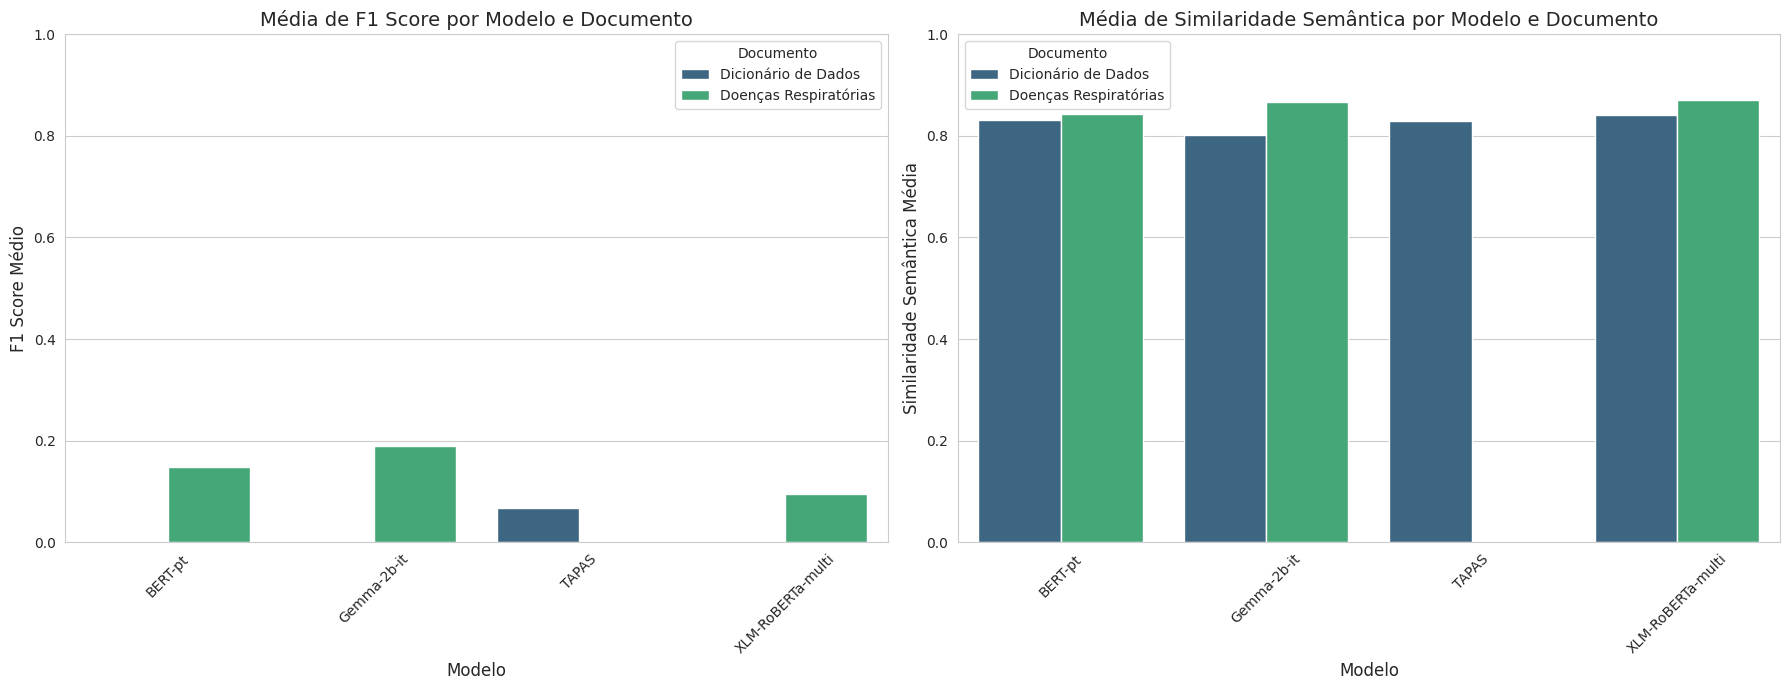

Análise dos Resultados:
A análise detalhada e as conclusões estão disponíveis no conteúdo do relatório gerado na próxima seção.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x='Modelo', y='F1 Score', hue='Documento', data=average_metrics, ax=axes[0], palette='viridis')
axes[0].set_title('Média de F1 Score por Modelo e Documento', fontsize=14)
axes[0].set_ylabel('F1 Score Médio', fontsize=12)
axes[0].set_xlabel('Modelo', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Documento')
axes[0].set_ylim(0, 1)

sns.barplot(x='Modelo', y='Semantic Similarity', hue='Documento', data=average_metrics, ax=axes[1], palette='viridis')
axes[1].set_title('Média de Similaridade Semântica por Modelo e Documento', fontsize=14)
axes[1].set_ylabel('Similaridade Semântica Média', fontsize=12)
axes[1].set_xlabel('Modelo', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Documento')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# A análise detalhada em texto gerada nos passos anteriores seria incluída aqui.
print("Análise dos Resultados:")
print("A análise detalhada e as conclusões estão disponíveis no conteúdo do relatório gerado na próxima seção.")